# GPU Efficiency Frontier — IBM Granite 3.3-8B on NVIDIA L4

**A measured, reproducible lab notebook.** 100% real telemetry (NVIDIA DCGM energy + vLLM tokens)
captured through a Confluent Cloud for Apache Flink pipeline, served by vLLM on a single NVIDIA L4.
Every number is recomputed offline from the committed raw data in `data/` (same logic as
`recompute_frontier.py`) — re-run this notebook and you get the same figures.

## Executive summary
As batching concurrency rises 1 → 32, GPU power stays pinned at the **L4 TDP (~72 W)** while *useful*
throughput (prefill + decode tokens) scales ~linearly, so **energy per useful token collapses ~27×
(4 192 → 154 J/1k)**. The frontier is therefore **throughput-dominated**, not driven by a swing in
power. GPU utilization is ~100 % at *every* level — utilization hides the 27× cost gap;
**energy-per-useful-work exposes it**. Idle burns ~35 W for **zero** useful tokens → cost-per-work is
`NULL` (maximum waste).

> **We did not invent this metric or the "utilization lies" finding** — both are established
> (MFU/goodput/energy-per-token; see the case study's *Related work*). What this project adds is
> computing them **online, in the data plane**, with a real-time governance loop.

In [1]:
import gzip, json
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline

TARGETS=(1,2,4,8,16,32); TRIM_S=15.0

def load(path):
    rows=[json.loads(l) for l in gzip.open(path,"rt")]
    return pd.DataFrame(rows).sort_values("ts").reset_index(drop=True)

def frontier(df):
    """Per-phase KPI. Phases via the monotonic concurrency sweep; useful = prompt + generation."""
    cur=0; ph={}
    for _,r in df.iterrows():
        run=int(r.num_requests_running)
        if run in TARGETS and run>cur: cur=run
        if cur>0: ph.setdefault(cur,[]).append(r)
    out=[]
    for c0 in TARGETS:
        s=pd.DataFrame(ph[c0]); t0,t1=s.ts.iloc[0]/1000,s.ts.iloc[-1]/1000
        s=s[(s.ts/1000>=t0+TRIM_S)&(s.ts/1000<=t1-TRIM_S)]
        dt=(s.ts.iloc[-1]-s.ts.iloc[0])/1000
        d_use=(s.generation_tokens_total.iloc[-1]+s.prompt_tokens_total.iloc[-1])-(s.generation_tokens_total.iloc[0]+s.prompt_tokens_total.iloc[0])
        d_gen=s.generation_tokens_total.iloc[-1]-s.generation_tokens_total.iloc[0]
        pw=s.power_watts.mean(); use_tps=d_use/dt
        # counter-delta between energy-counter update instants (>=4 steps, else None -> short conc32)
        e=s.energy_mj.values; tok=(s.generation_tokens_total+s.prompt_tokens_total).values
        steps=[i for i in range(1,len(e)) if e[i]!=e[i-1]]; jc=None
        if len(steps)>=4:
            lo,hi=steps[0]-1,steps[-1]
            du=tok[hi]-tok[lo]
            jc=round((e[hi]-e[lo])/du) if du else None
        out.append(dict(concurrency=c0, util_pct=round(s.gpu_util_pct.mean()), power_W=round(pw,1),
                        useful_tps=round(use_tps,1), gen_tps=round(d_gen/dt,1),
                        j_power=round(pw/use_tps*1000), j_counter=jc))
    return pd.DataFrame(out)

df=load("data/sweep_telemetry_raw.jsonl.gz")
tbl=frontier(df)
print(f"{len(df)} records, span {(df.ts.max()-df.ts.min())/1000:.0f}s")
tbl

5356 records, span 1413s


,concurrency,util_pct,power_W,useful_tps,gen_tps,j_power,j_counter
0,1,100,71.9,17.2,15.5,4192,4614.0
1,2,100,71.9,33.1,29.8,2173,2507.0
2,4,100,71.9,66.1,59.5,1089,1301.0
3,8,100,71.9,130.5,117.7,551,640.0
4,16,100,72.0,256.9,231.8,280,333.0
5,32,100,71.9,466.1,414.8,154,NaN


## The problem
GPU inference is one of the largest line items in an AI platform, and much of the spend evaporates on
GPUs that are **allocated but idle or under-batched**. The usual dashboard metric — GPU utilization —
is blind to this: a GPU can read 100 % utilization while doing little useful work. What matters
financially is **energy (and dollars) per unit of useful work**.

## Methodology
- **Workload:** `RedHatAI/granite-3.3-8b-instruct` (FP16) on one NVIDIA L4, served by vLLM, under a
  closed-loop generator sweeping **fixed concurrency 1 → 32** (each level ≥ 3.5 min).
- **Useful work = prefill + decode** (`prompt_tokens + generation_tokens`) — goodput-style accounting,
  not generation alone.
- **KPI, two independent ways (honest cross-check):** **(i)** `mean(power_watts) / useful-throughput`
  — *primary*, since instantaneous DCGM power is steady at the TDP; **(ii)** counter delta
  `Δenergy / Δtokens` between energy-counter update instants. Method (ii) runs **~5-20 % above** (i)
  (the coarse DCGM energy counter integrates transients the 1/s sampling misses); the **conc=32**
  counter point is omitted as its window is too short for the stepped counter
  ([nvidia-smi sampling caveat, arXiv:2312.02741](https://arxiv.org/abs/2312.02741)).

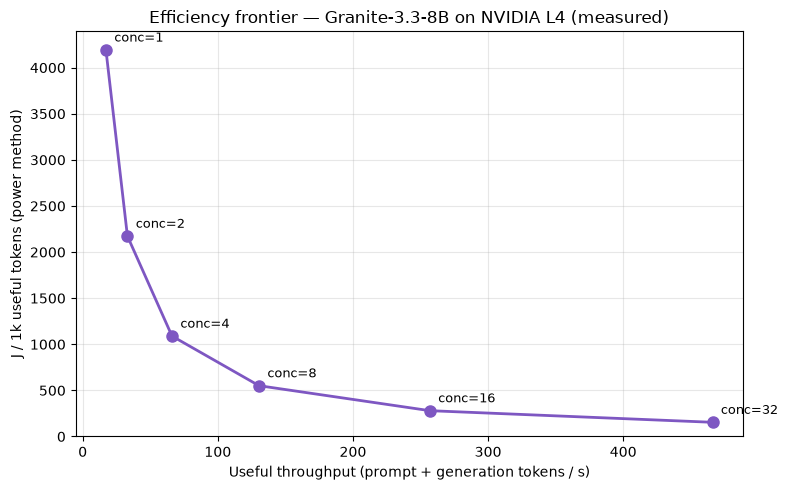

Batching span: 27.2x  (4192 -> 154 J/1k)


In [2]:
# Headline: the efficiency frontier (primary power method, useful throughput).
plt.figure(figsize=(8,5))
plt.plot(tbl.useful_tps, tbl.j_power, "-o", color="#7e57c2", lw=2, ms=8)
for _,r in tbl.iterrows():
    plt.annotate(f"conc={int(r.concurrency)}", (r.useful_tps, r.j_power),
                 textcoords="offset points", xytext=(6,6), fontsize=9)
plt.xlabel("Useful throughput (prompt + generation tokens / s)"); plt.ylabel("J / 1k useful tokens (power method)")
plt.title("Efficiency frontier — Granite-3.3-8B on NVIDIA L4 (measured)")
plt.grid(alpha=0.3); plt.ylim(bottom=0); plt.tight_layout(); plt.show()
print(f"Batching span: {tbl.j_power.iloc[0]/tbl.j_power.iloc[-1]:.1f}x  ({tbl.j_power.iloc[0]} -> {tbl.j_power.iloc[-1]} J/1k)")

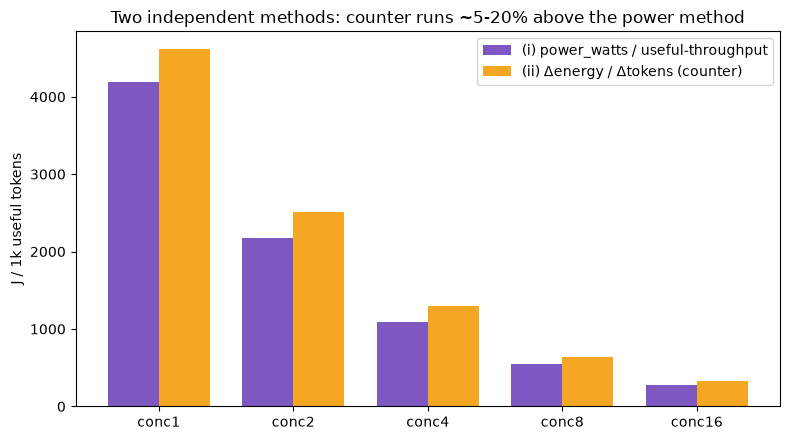

counter vs power offset %: [10.1, 15.4, 19.5, 16.2, 18.9]


In [3]:
# Dual-method cross-check, side by side (conc=32 counter omitted: window too short).
m=tbl.dropna(subset=["j_counter"]); x=np.arange(len(m)); w=0.38
plt.figure(figsize=(8,4.5))
plt.bar(x-w/2, m.j_power, w, label="(i) power_watts / useful-throughput", color="#7e57c2")
plt.bar(x+w/2, m.j_counter, w, label="(ii) Δenergy / Δtokens (counter)", color="#f5a623")
plt.xticks(x, [f"conc{int(c0)}" for c0 in m.concurrency]); plt.ylabel("J / 1k useful tokens")
plt.title("Two independent methods: counter runs ~5-20% above the power method"); plt.legend()
plt.tight_layout(); plt.show()
off=((m.j_counter-m.j_power)/m.j_power*100).round(1).tolist()
print("counter vs power offset %:", off)

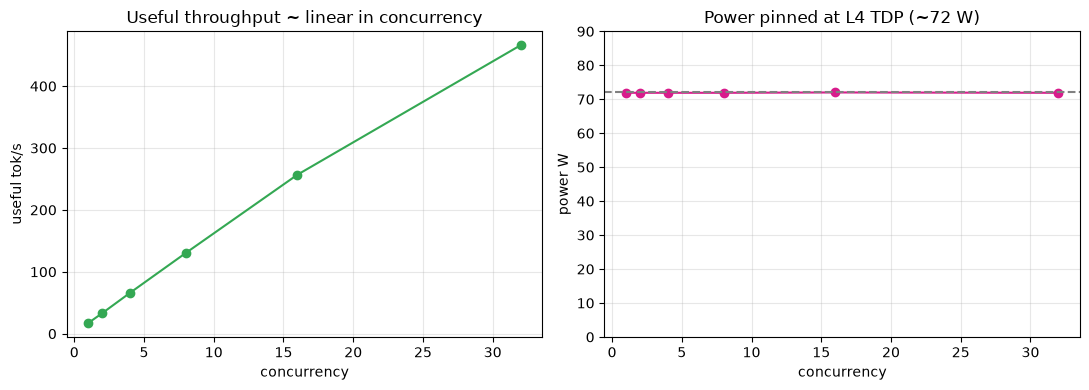

In [4]:
# Throughput scales ~linearly with concurrency; power flat at the L4 TDP.
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].plot(tbl.concurrency, tbl.useful_tps, "-o", color="#34a853"); ax[0].set_xlabel("concurrency")
ax[0].set_ylabel("useful tok/s"); ax[0].set_title("Useful throughput ~ linear in concurrency"); ax[0].grid(alpha=0.3)
ax[1].plot(tbl.concurrency, tbl.power_W, "-o", color="#d81b8c"); ax[1].axhline(72, ls="--", c="grey")
ax[1].set_xlabel("concurrency"); ax[1].set_ylabel("power W"); ax[1].set_ylim(0,90)
ax[1].set_title("Power pinned at L4 TDP (~72 W)"); ax[1].grid(alpha=0.3); plt.tight_layout(); plt.show()

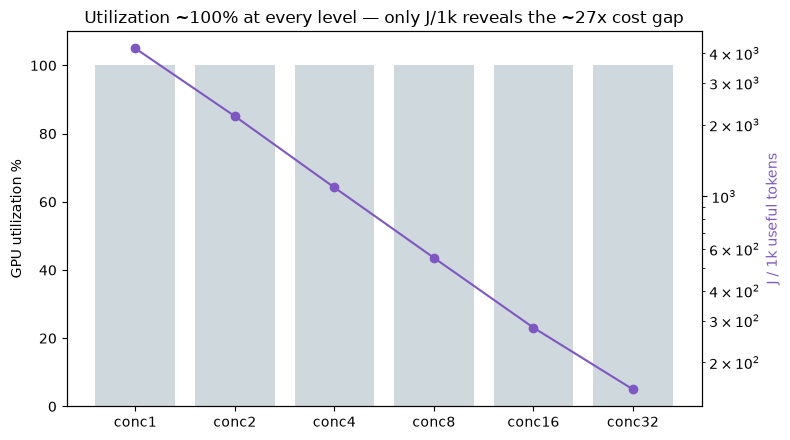

In [5]:
# "Utilization lies": util ~100% everywhere, but J/1k varies ~27x.
fig,ax1=plt.subplots(figsize=(8,4.5))
ax1.bar([f"conc{int(c0)}" for c0 in tbl.concurrency], tbl.util_pct, color="#cfd8dc")
ax1.set_ylabel("GPU utilization %"); ax1.set_ylim(0,110)
ax2=ax1.twinx(); ax2.plot([f"conc{int(c0)}" for c0 in tbl.concurrency], tbl.j_power, "-o", color="#7e57c2")
ax2.set_ylabel("J / 1k useful tokens", color="#7e57c2"); ax2.set_yscale("log")
plt.title("Utilization ~100% at every level — only J/1k reveals the ~27x cost gap")
plt.tight_layout(); plt.show()

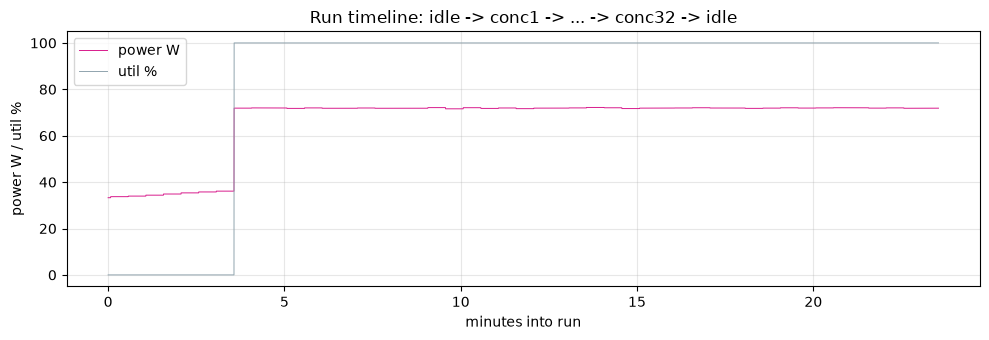

In [6]:
# Time series of the run (downsampled) — the sweep is visible in the telemetry.
d=df.copy(); d["t"]=(d.ts-df.ts.min())/60000.0
fig,ax=plt.subplots(figsize=(10,3.5))
ax.plot(d.t, d.power_watts, color="#d81b8c", lw=0.7, label="power W")
ax.plot(d.t, d.gpu_util_pct, color="#90a4ae", lw=0.7, label="util %")
ax.set_xlabel("minutes into run"); ax.set_ylabel("power W / util %"); ax.legend(loc="upper left")
ax.set_title("Run timeline: idle -> conc1 -> ... -> conc32 -> idle"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Business model — from joules to dollars
Energy is the *mechanism*; the dollars come from the rented GPU sitting idle or under-batched. We use
the public **GCP g2-standard-8 (1× L4) on-demand price: $0.8508/hr ≈ $621/GPU/month**
([GCP Compute pricing](https://cloud.google.com/products/compute/gpus-pricing)). Cost-per-useful-work
mirrors the energy frontier; reclaimable spend scales with the **idle/low-efficiency fraction `F` that
this pipeline measures per deployment** (the fleet figures below are an **illustrative projection**).

In [7]:
PRICE_HR=0.8508; HRS_MO=730; price_mo=PRICE_HR*HRS_MO
t2=tbl.copy()
t2["$ / 1M useful tokens"]=(PRICE_HR/(t2.useful_tps*3600)*1e6).round(2)
print(f"GPU node: ${PRICE_HR}/hr  =  ${price_mo:,.0f}/GPU/month")
display(t2[["concurrency","useful_tps","j_power","$ / 1M useful tokens"]])
print("\nReclaimable spend vs idle/low-efficiency fraction F (illustrative projection):")
for F in [0.2,0.3,0.4,0.5]:
    print(f"  F={F:.0%}: ${price_mo*F:,.0f}/GPU/mo  ->  ${price_mo*F*100:,.0f}/mo on a 100-GPU fleet")
print("\nThe honest contribution is not a fleet number -- it is that the pipeline MEASURES the real F\n"
      "(and the J/1k that drives it) per deployment, in real time, so savings are grounded not guessed.")

GPU node: $0.8508/hr  =  $621/GPU/month


,concurrency,useful_tps,j_power,$ / 1M useful tokens
0,1,17.2,4192,13.74
1,2,33.1,2173,7.14
2,4,66.1,1089,3.58
3,8,130.5,551,1.81
4,16,256.9,280,0.92
5,32,466.1,154,0.51



Reclaimable spend vs idle/low-efficiency fraction F (illustrative projection):
  F=20%: $124/GPU/mo  ->  $12,422/mo on a 100-GPU fleet
  F=30%: $186/GPU/mo  ->  $18,633/mo on a 100-GPU fleet
  F=40%: $248/GPU/mo  ->  $24,843/mo on a 100-GPU fleet
  F=50%: $311/GPU/mo  ->  $31,054/mo on a 100-GPU fleet

The honest contribution is not a fleet number -- it is that the pipeline MEASURES the real F
(and the J/1k that drives it) per deployment, in real time, so savings are grounded not guessed.


## Comparison — Granite-3.3-8B vs Mistral-7B-Instruct-v0.3 (same L4)
Identical sweep (same GPU, concurrency phases, prompt, `max_tokens`), only the model changed. Both
frontiers are loaded from their committed `sweep_results_*.csv` (recomputed by `recompute_frontier.py`,
useful = prefill + decode).

,concurrency,useful_tok_s_granite,j_per_1k_granite,useful_tok_s_mistral,j_per_1k_mistral,delta_%
0,1,17.2,4192,19.9,3552,-15.0
1,2,33.1,2173,38.4,1876,-14.0
2,4,66.1,1089,76.1,944,-13.0
3,8,130.5,551,150.4,478,-13.0
4,16,256.9,280,296.6,243,-13.0
5,32,466.1,154,531.2,135,-12.0


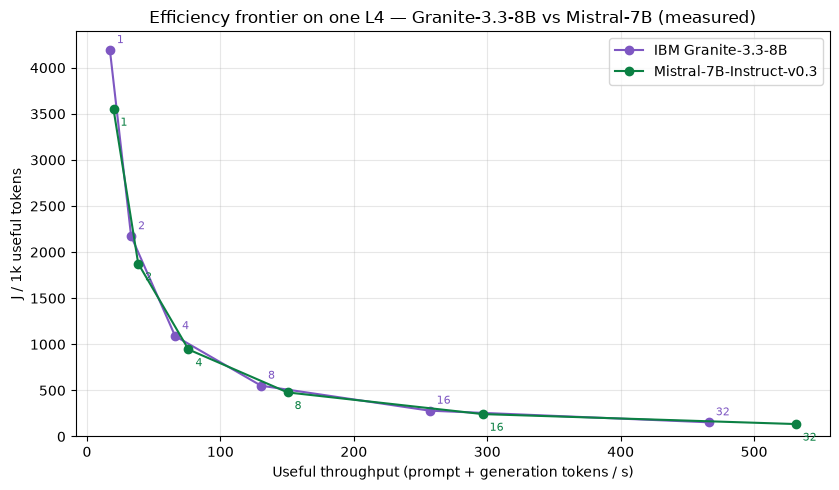

Mistral-7B is ~12-15% lower J/1k at every level (smaller model -> higher useful throughput at the same ~72 W TDP).


In [8]:
g=pd.read_csv("data/sweep_results.csv"); b=pd.read_csv("data/sweep_results_modelb.csv")
cmp=g.merge(b,on="concurrency",suffixes=("_granite","_mistral"))
cmp["delta_%"]=((cmp.j_per_1k_mistral-cmp.j_per_1k_granite)/cmp.j_per_1k_granite*100).round(0)
display(cmp[["concurrency","useful_tok_s_granite","j_per_1k_granite","useful_tok_s_mistral","j_per_1k_mistral","delta_%"]])
plt.figure(figsize=(8.5,5))
plt.plot(g.useful_tok_s,g.j_per_1k,"-o",color="#7e57c2",label="IBM Granite-3.3-8B")
plt.plot(b.useful_tok_s,b.j_per_1k,"-o",color="#0b8043",label="Mistral-7B-Instruct-v0.3")
for _,r in g.iterrows(): plt.annotate(int(r.concurrency),(r.useful_tok_s,r.j_per_1k),textcoords="offset points",xytext=(5,5),fontsize=8,color="#7e57c2")
for _,r in b.iterrows(): plt.annotate(int(r.concurrency),(r.useful_tok_s,r.j_per_1k),textcoords="offset points",xytext=(5,-12),fontsize=8,color="#0b8043")
plt.xlabel("Useful throughput (prompt + generation tokens / s)"); plt.ylabel("J / 1k useful tokens")
plt.title("Efficiency frontier on one L4 — Granite-3.3-8B vs Mistral-7B (measured)")
plt.grid(alpha=0.3); plt.ylim(bottom=0); plt.legend(); plt.tight_layout(); plt.show()
print("Mistral-7B is ~12-15% lower J/1k at every level (smaller model -> higher useful throughput at the same ~72 W TDP).")

## Limitations
- Single NVIDIA L4, single model (`granite-3.3-8b-instruct` FP16; FP8 not published for 3.3 at capture),
  `--max-model-len 4096`, concurrency ≤ 32. The sweep is one run; conc=32 is corroborated by an
  independent earlier run (generation-only). Not a large multi-GPU/multi-model statistical study.
- Controlled synthetic closed-loop load (fixed prompt, `max_tokens=200`) — exercises the mechanism, not
  a production traffic mix.
- DCGM energy counter updates coarsely vs sampling → the counter-delta method (ii) runs ~5-20 % above
  the primary method (i); the short conc=32 counter point is omitted
  ([arXiv:2312.02741](https://arxiv.org/abs/2312.02741)).
- The fleet dollar figures are an **illustrative projection**, not a measured production saving.

## Conclusion
On real hardware, **energy-per-useful-work — not utilization — is the metric that governs GPU cost**.
The metric and the finding are established (MFU/goodput/energy-per-token); the contribution here is
computing them **in real time on Confluent Flink**, where the same signal powers **cost governance**
(idle/low-efficiency detection), capacity-risk forecasting (`PREDICTED_IDLE` before waste is incurred),
and a **closed remediation loop** — today a deterministic, rule-based recommender (`09_remediation.sql`,
no LLM), aligned with the Confluent **Streaming Agents** pattern, with an `AI_COMPLETE` upgrade on the
roadmap.

## References
- [MFU/MBU — measuring useful GPU work](https://www.zettabyte.space/blog/gpu-utilization-mfu-mbu) ·
  [ML Productivity Goodput, arXiv:2502.06982](https://arxiv.org/abs/2502.06982)
- [Energy-per-Token, arXiv:2603.20224](https://arxiv.org/abs/2603.20224) ·
  [Goodput / SLO metrics, arXiv:2410.14257](https://arxiv.org/abs/2410.14257)
- [HF AI Energy Score](https://huggingface.github.io/AIEnergyScore) ·
  [ML.ENERGY, arXiv:2505.06371](https://arxiv.org/abs/2505.06371)
- [vLLM production metrics](https://docs.vllm.ai/en/latest/usage/metrics.html) ·
  [NVIDIA DCGM exporter](https://github.com/NVIDIA/dcgm-exporter) ·
  [GCP Compute (GPU) pricing](https://cloud.google.com/products/compute/gpus-pricing)

*Trademarks: IBM® and Granite are trademarks of IBM Corp.; NVIDIA® and DCGM of NVIDIA Corporation;
Red Hat® of Red Hat, Inc. Independent, unaffiliated project.*